# MIOFlow

## Workflow
1. Load pre-processed SERGIO simulation AnnData
2. Train a **GAGA autoencoder** (`gaga.py`) — learns a geometry-preserving latent embedding from PCA, regularised by PHATE distances
3. Pass the trained GAGA model to `MIOFlow` and call `fit()` — trains a Neural ODE in GAGA latent space using optimal transport
4. Inspect losses and trajectories
5. `decode_to_gene_space()` — maps trajectories back through the GAGA decoder and PCA components to recover gene-level predictions

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from mioflow import MIOFlow, fit_gaga


## 1. Load Data

In [3]:
adata = sc.read_h5ad('data/scRNAseq/preprocessed_eb_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 16826 × 17845
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'pca', 'timepoint_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'

Set the time_column for your dataset

In [4]:
time_column = 'time_bin'  # Set the time_column for your dataset

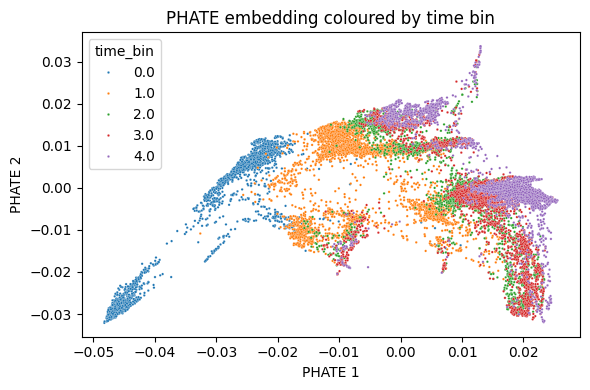

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    x=adata.obsm['X_phate'][:, 0],
    y=adata.obsm['X_phate'][:, 1],
    hue=adata.obs[time_column],
    palette='tab10',
    s=3,
    ax=ax,
)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_title('PHATE embedding coloured by time bin')
plt.tight_layout()
plt.show()

## 2. Train GAGA Autoencoder

GAGA (`gaga.py`) trains a two-phase autoencoder on PCA embeddings, regularised by PHATE distances:

- **Phase 1** — encoder learns a geometry-preserving latent space (distance preservation loss, decoder frozen)
- **Phase 2** — decoder learns to reconstruct PCA coordinates (reconstruction loss, encoder frozen)

The resulting latent space is where the MIOFlow ODE will be trained.

In [6]:
gaga_model = fit_gaga(
    X_pca      = adata.obsm['X_pca'],
    X_phate    = adata.obsm['X_phate'],
    latent_dim = 2,
    hidden_dims= [128, 64],
    batch_size = 1024,
    encoder_epochs=300,
    decoder_epochs=300,
    learning_rate=1e-3,
    dist_weight_phase1=1.0,
    recon_weight_phase2=1.0,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cpu
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|██████████| 300/300 [01:12<00:00,  4.15it/s, train_loss=0.0065, recon=1.0242, dist=0.0065]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cpu
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|██████████| 300/300 [00:43<00:00,  6.85it/s, train_loss=0.7529, recon=0.7529, dist=0.0064]


In [9]:
adata

AnnData object with n_obs × n_vars = 16826 × 17845
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'pca', 'timepoint_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'

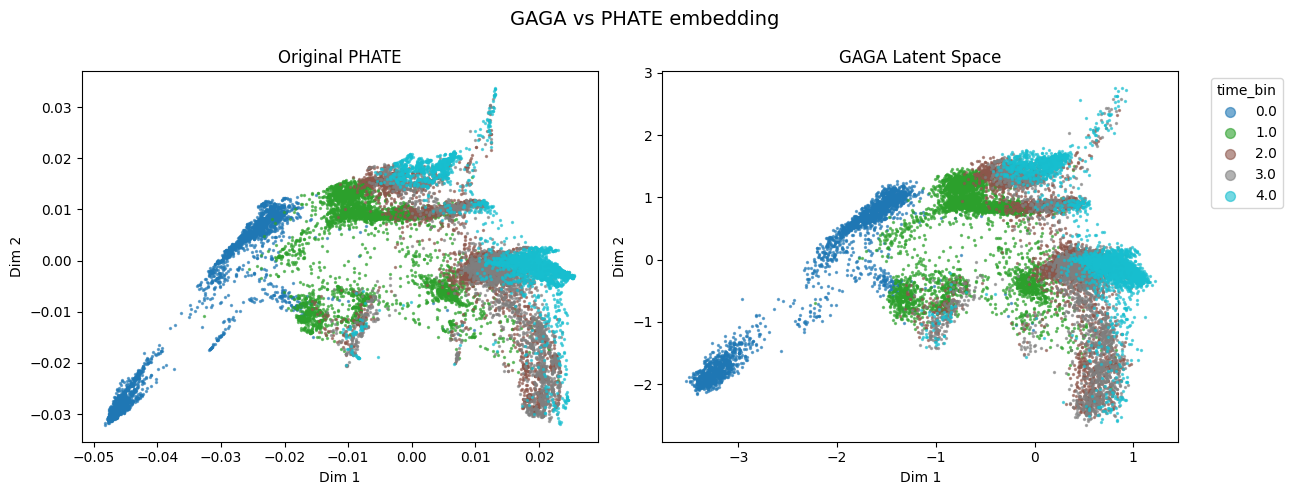

In [10]:
# quick sanity-check: compare GAGA latent space with original PHATE
X_pca_scaled = gaga_model.input_scaler.transform(adata.obsm['X_pca'].astype('float32'))
gaga_model.eval()
with torch.no_grad():
    gaga_embeddings = gaga_model.encode(torch.tensor(X_pca_scaled)).numpy()

adata.obsm['X_gaga'] = gaga_embeddings

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = adata.obs[time_column].astype('category').cat
codes = categories.codes.values
cat_names = categories.categories
colors = plt.cm.tab10(np.linspace(0, 1, len(cat_names)))

for ax, key, title in zip(
    axes,
    ['X_phate', 'X_gaga'],
    ['Original PHATE', 'GAGA Latent Space'],
):
    for i, name in enumerate(cat_names):
        mask = codes == i
        ax.scatter(
            adata.obsm[key][mask, 0], adata.obsm[key][mask, 1],
            color=colors[i], s=2, alpha=0.6, label=name,
        )
    ax.set_title(title)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

axes[-1].legend(title=time_column, bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5)
plt.suptitle('GAGA vs PHATE embedding', fontsize=14)
plt.tight_layout()
plt.show()

# Branching identificaton

K-means clusters found: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')]


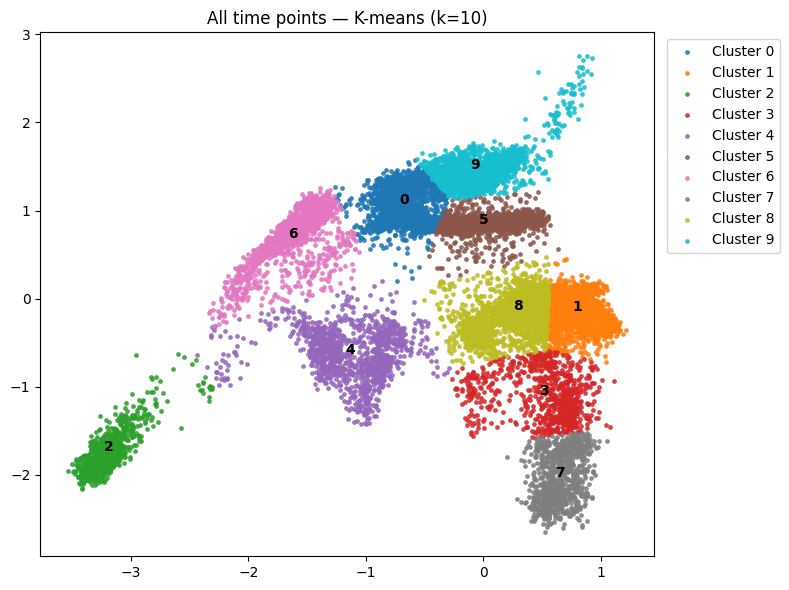

In [13]:
from sklearn.cluster import KMeans

# ── K-means clustering on ALL time points ────────────────────────────────────
X_all = adata.obsm['X_gaga']

n_clusters = 10   # ← tune this
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_all).astype(str)
print('K-means clusters found:', sorted(set(cluster_labels), key=int))

# ── Store in adata for downstream use ─────────────────────────────────────────
adata.obs['kmeans_cluster'] = cluster_labels

# ── Visualise clusters ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
palette = plt.cm.tab10.colors
for cl in sorted(set(cluster_labels), key=int):
    mask_cl = cluster_labels == cl
    ax.scatter(
        X_all[mask_cl, 0], X_all[mask_cl, 1],
        s=6, alpha=0.8, color=palette[int(cl) % 10], label=f'Cluster {cl}',
    )
    centroid = X_all[mask_cl].mean(axis=0)
    ax.annotate(f'{cl}', centroid, fontsize=10, fontweight='bold', ha='center')

ax.set_title(f'All time points — K-means (k={n_clusters})')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

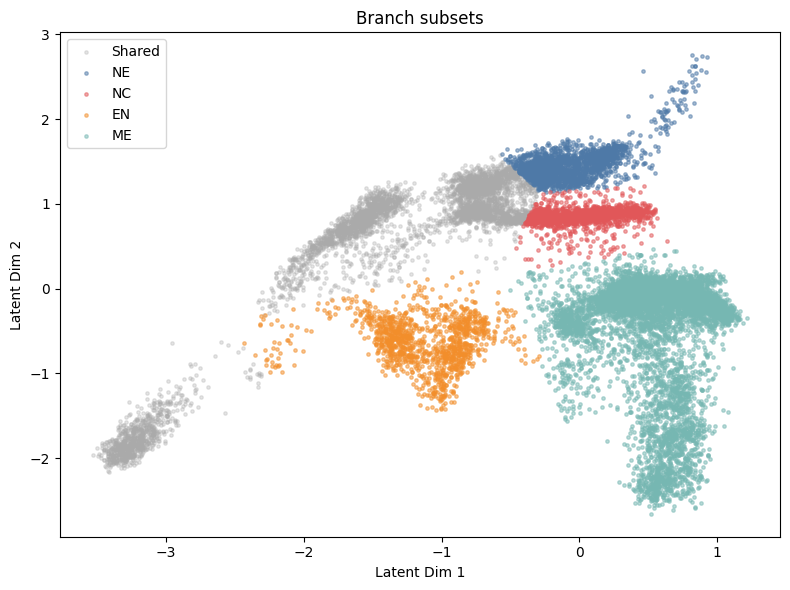

In [35]:
from collections import Counter

cluster_to_branches = {
    '0': ['NE','NC'],
    '1': ['ME'],
    '2': ['NE','NC','EN','ME'],
    '3': ['ME'],
    '4': ['EN'],
    '5': ['NC'],
    '6': ['NE','NC','ME'],
    '7': ['ME'],
    '8': ['ME'],
    '9': ['NE'],
}

adata_branches = {}
for branch_name in ['NE','NC','EN','ME']:
    branch_mask = np.array([
        cluster_labels[i] in cluster_to_branches
        and branch_name in cluster_to_branches[cluster_labels[i]]
        for i in range(adata.n_obs)
    ])
    adata_branches[branch_name] = adata[branch_mask].copy()

branch_colors = {'NE': '#4E79A7', 'NC': '#E15759', 'EN': '#F28E2B', 'ME': '#76B7B2'}

# Find cells in multiple branches
cell_branch = Counter()
for branch_name in branch_colors:
    for idx in adata_branches[branch_name].obs_names:
        cell_branch[idx] += 1
shared_cells = {c for c, count in cell_branch.items() if count > 1}

fig, ax = plt.subplots(figsize=(8, 6))

# Plot shared cells once (gray, behind) — use full adata to avoid duplicates
shared_mask = np.array([c in shared_cells for c in adata.obs_names])
if shared_mask.any():
    X = adata.obsm['X_gaga'][shared_mask]
    ax.scatter(X[:, 0], X[:, 1], s=6, alpha=0.3, color='#AAAAAA',
               label='Shared', zorder=1)

# Plot unique cells on top
for branch_name, color in branch_colors.items():
    adata_b = adata_branches[branch_name]
    mask = np.array([c not in shared_cells for c in adata_b.obs_names])
    if mask.any():
        X = adata_b.obsm['X_gaga'][mask]
        ax.scatter(X[:, 0], X[:, 1], s=6, alpha=0.5, color=color,
                   label=branch_name, zorder=2)

ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_title('Branch subsets')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Configure and Initialise MIOFlow

Pass the trained `gaga_model` and `scaler_pca` (the scaler fitted on `X_pca` before GAGA training).  
`MIOFlow` will use the encoder to embed cells into latent space for ODE training, and the decoder in `decode_to_gene_space()`.

In [20]:
mioflow_models = {}
for branch in ['NE','NC','EN','ME']:
    mioflow_models[branch] = MIOFlow(
        adata_branches[branch],
        gaga_model=gaga_model,
        obs_time_key=time_column,
        debug_level='info',
        hidden_dim=32,
        use_cuda=torch.cuda.is_available(),
        momentum_beta=0.0,
        scheduler_type='cosine',
        learning_rate=1e-4,
        scheduler_t_max=100,
        scheduler_min_lr=1e-5,
        n_epochs=300,
        use_density_loss=True,
        lambda_ot=1.0,
        lambda_density=0.00,
        lambda_energy=0.1,
        energy_time_steps=20,
        sample_size=None,
        n_trajectories=50,
        n_bins=100,
        exp_dir='.',
    )


2026-03-30 11:15:56,051 - MIOFlow - INFO - MIOFlow initialised | 6427 cells, 17845 genes | device=cpu
2026-03-30 11:15:56,055 - MIOFlow - INFO - MIOFlow initialised | 6097 cells, 17845 genes | device=cpu
2026-03-30 11:15:56,057 - MIOFlow - INFO - MIOFlow initialised | 2032 cells, 17845 genes | device=cpu
2026-03-30 11:15:56,062 - MIOFlow - INFO - MIOFlow initialised | 9880 cells, 17845 genes | device=cpu


## 4. Fit — `~5 minutes`

`fit()` runs three phases under the hood:
1. **Training** (`n_local_epochs`) — trains each consecutive time-point pair independently

The ODE operates entirely in the GAGA latent space.

In [21]:
mioflow_models

{'NE': MIOFlow(n_obs=6427, gaga=Autoencoder, n_epochs=300, trajectories=None, status=not fitted),
 'NC': MIOFlow(n_obs=6097, gaga=Autoencoder, n_epochs=300, trajectories=None, status=not fitted),
 'EN': MIOFlow(n_obs=2032, gaga=Autoencoder, n_epochs=300, trajectories=None, status=not fitted),
 'ME': MIOFlow(n_obs=9880, gaga=Autoencoder, n_epochs=300, trajectories=None, status=not fitted)}

In [22]:
for branch, model in mioflow_models.items():
    print(f'\n── Fitting branch: {branch} ──')
    model.fit()
    print(model)

2026-03-30 11:16:03,123 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=32
2026-03-30 11:16:03,123 - MIOFlow - INFO - Global training: 300 epochs



── Fitting branch: NE ──


Training (global):   0%|          | 0/300 [00:00<?, ?it/s]/Users/joaofelipe/Yale/github_projects/MIOFlow/.venv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)
Training (global): 100%|██████████| 300/300 [06:03<00:00,  1.21s/it]
2026-03-30 11:22:06,733 - MIOFlow - INFO - Trajectories generated: shape=(100, 50, 2)
2026-03-30 11:22:06,734 - MIOFlow - INFO - MIOFlow fitting completed.
2026-03-30 11:22:06,737 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=32
2026-03-30 11:22:06,738 - MIOFlow - INFO - Global training: 300 epochs


MIOFlow(n_obs=6427, gaga=Autoencoder, n_epochs=300, trajectories=(100, 50, 2), status=fitted)

── Fitting branch: NC ──


Training (global): 100%|██████████| 300/300 [06:51<00:00,  1.37s/it]
2026-03-30 11:28:58,187 - MIOFlow - INFO - Trajectories generated: shape=(100, 50, 2)
2026-03-30 11:28:58,187 - MIOFlow - INFO - MIOFlow fitting completed.
2026-03-30 11:28:58,188 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=32
2026-03-30 11:28:58,189 - MIOFlow - INFO - Global training: 300 epochs


MIOFlow(n_obs=6097, gaga=Autoencoder, n_epochs=300, trajectories=(100, 50, 2), status=fitted)

── Fitting branch: EN ──


Training (global): 100%|██████████| 300/300 [01:31<00:00,  3.26it/s]
2026-03-30 11:30:30,159 - MIOFlow - INFO - Trajectories generated: shape=(100, 50, 2)
2026-03-30 11:30:30,159 - MIOFlow - INFO - MIOFlow fitting completed.
2026-03-30 11:30:30,160 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=32
2026-03-30 11:30:30,160 - MIOFlow - INFO - Global training: 300 epochs


MIOFlow(n_obs=2032, gaga=Autoencoder, n_epochs=300, trajectories=(100, 50, 2), status=fitted)

── Fitting branch: ME ──


Training (global): 100%|██████████| 300/300 [09:31<00:00,  1.91s/it]
2026-03-30 11:40:02,070 - MIOFlow - INFO - Trajectories generated: shape=(100, 50, 2)
2026-03-30 11:40:02,071 - MIOFlow - INFO - MIOFlow fitting completed.


MIOFlow(n_obs=9880, gaga=Autoencoder, n_epochs=300, trajectories=(100, 50, 2), status=fitted)


## 4. Training Losses

After fitting:
- `mf.losses` — list of dicts `{'Total', 'OT', 'Density', 'Energy'}` per epoch (local phase)

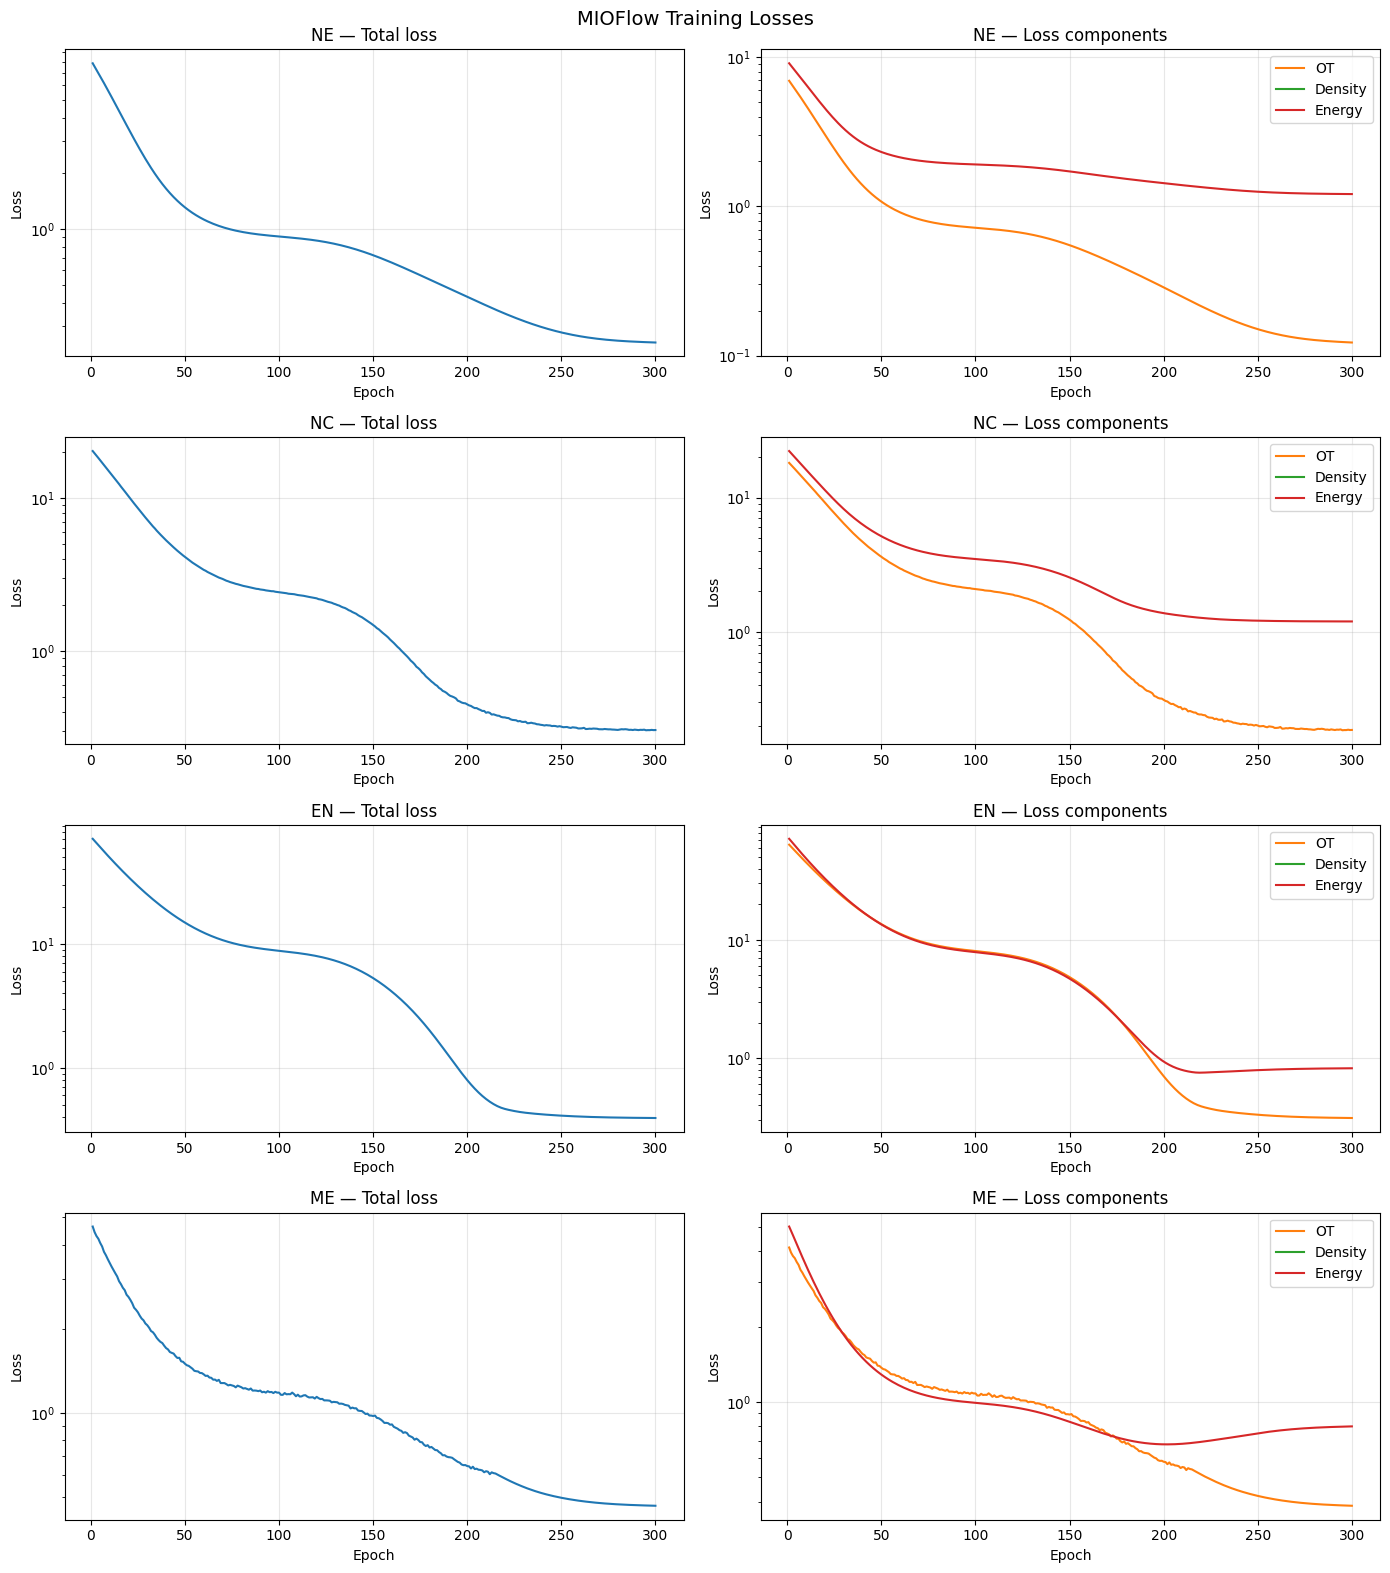

In [25]:
n_models = len(mioflow_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))

# Ensure axes is 2D even if there's only one model
if n_models == 1:
    axes = axes[np.newaxis, :]

for row, (branch, model) in enumerate(mioflow_models.items()):
    epochs = model.losses['epoch']

    axes[row, 0].plot(epochs, model.losses['total_loss'], color='tab:blue')
    axes[row, 0].set_title(f'{branch} — Total loss')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].set_yscale('log')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(epochs, model.losses['ot_loss'],      label='OT',      color='tab:orange')
    axes[row, 1].plot(epochs, model.losses['density_loss'], label='Density', color='tab:green')
    axes[row, 1].plot(epochs, model.losses['energy_loss'],  label='Energy',  color='tab:red')
    axes[row, 1].set_title(f'{branch} — Loss components')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Loss')
    axes[row, 1].set_yscale('log')
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle('MIOFlow Training Losses', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Trajectories in GAGA Latent Space

`mf.trajectories` has shape **`(n_bins, n_trajectories, latent_dim)`**.

To iterate over individual trajectories use `mf.trajectories[:, i, :]`.

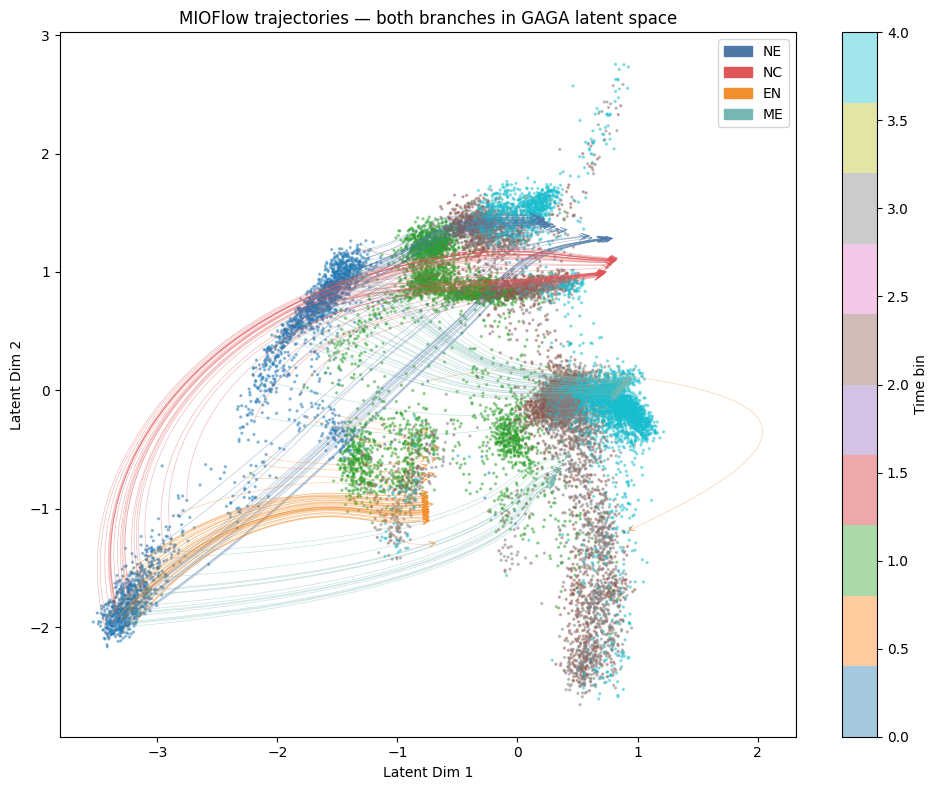

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 8))

# Background: all cells from full adata
sc_plot = ax.scatter(
    adata.obsm['X_gaga'][:, 0], adata.obsm['X_gaga'][:, 1],
    c=adata.obs[time_column], cmap='tab10', s=2, alpha=0.4,
)
plt.colorbar(sc_plot, ax=ax, label='Time bin')

for branch, model in mioflow_models.items():
    color = branch_colors[branch]
    for traj in model.trajectories.transpose(1, 0, 2):
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.4, linewidth=0.5, color=color)
        ax.annotate(
            '', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
            arrowprops=dict(arrowstyle='->', color=color, lw=0.5, mutation_scale=10),
        )

# Legend patches

ax.legend(handles=[Patch(color=c, label=b) for b, c in branch_colors.items()])
ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_title('MIOFlow trajectories — both branches in GAGA latent space')
plt.tight_layout()
plt.show()


## 6. Decode to Gene Space

`decode_to_gene_space()` maps trajectories through the chain:

**GAGA latent → GAGA decoder → PCA space (inverse scaler) → gene space**

Returns shape **`(n_bins, n_trajectories, n_genes)`**.

In [32]:
trajectories_gene_space = {
    branch: model.decode_to_gene_space()
    for branch, model in mioflow_models.items()
}
# Shape per branch: (n_bins, n_trajectories, n_genes)
# Combined along trajectory axis for shared analyses:
trajectories_gene_space_all = np.concatenate(
    list(trajectories_gene_space.values()), axis=1
)
print('Per-branch shapes:', {b: t.shape for b, t in trajectories_gene_space.items()})
print('Combined shape (n_bins, n_traj_total, n_genes):', trajectories_gene_space_all.shape)


Per-branch shapes: {'NE': (100, 50, 17845), 'NC': (100, 50, 17845), 'EN': (100, 50, 17845), 'ME': (100, 50, 17845)}
Combined shape (n_bins, n_traj_total, n_genes): (100, 200, 17845)


## 7. Gene Trends — Top Highly-Variable Genes

We plot the mean expression (± std) over all trajectories at each time bin.

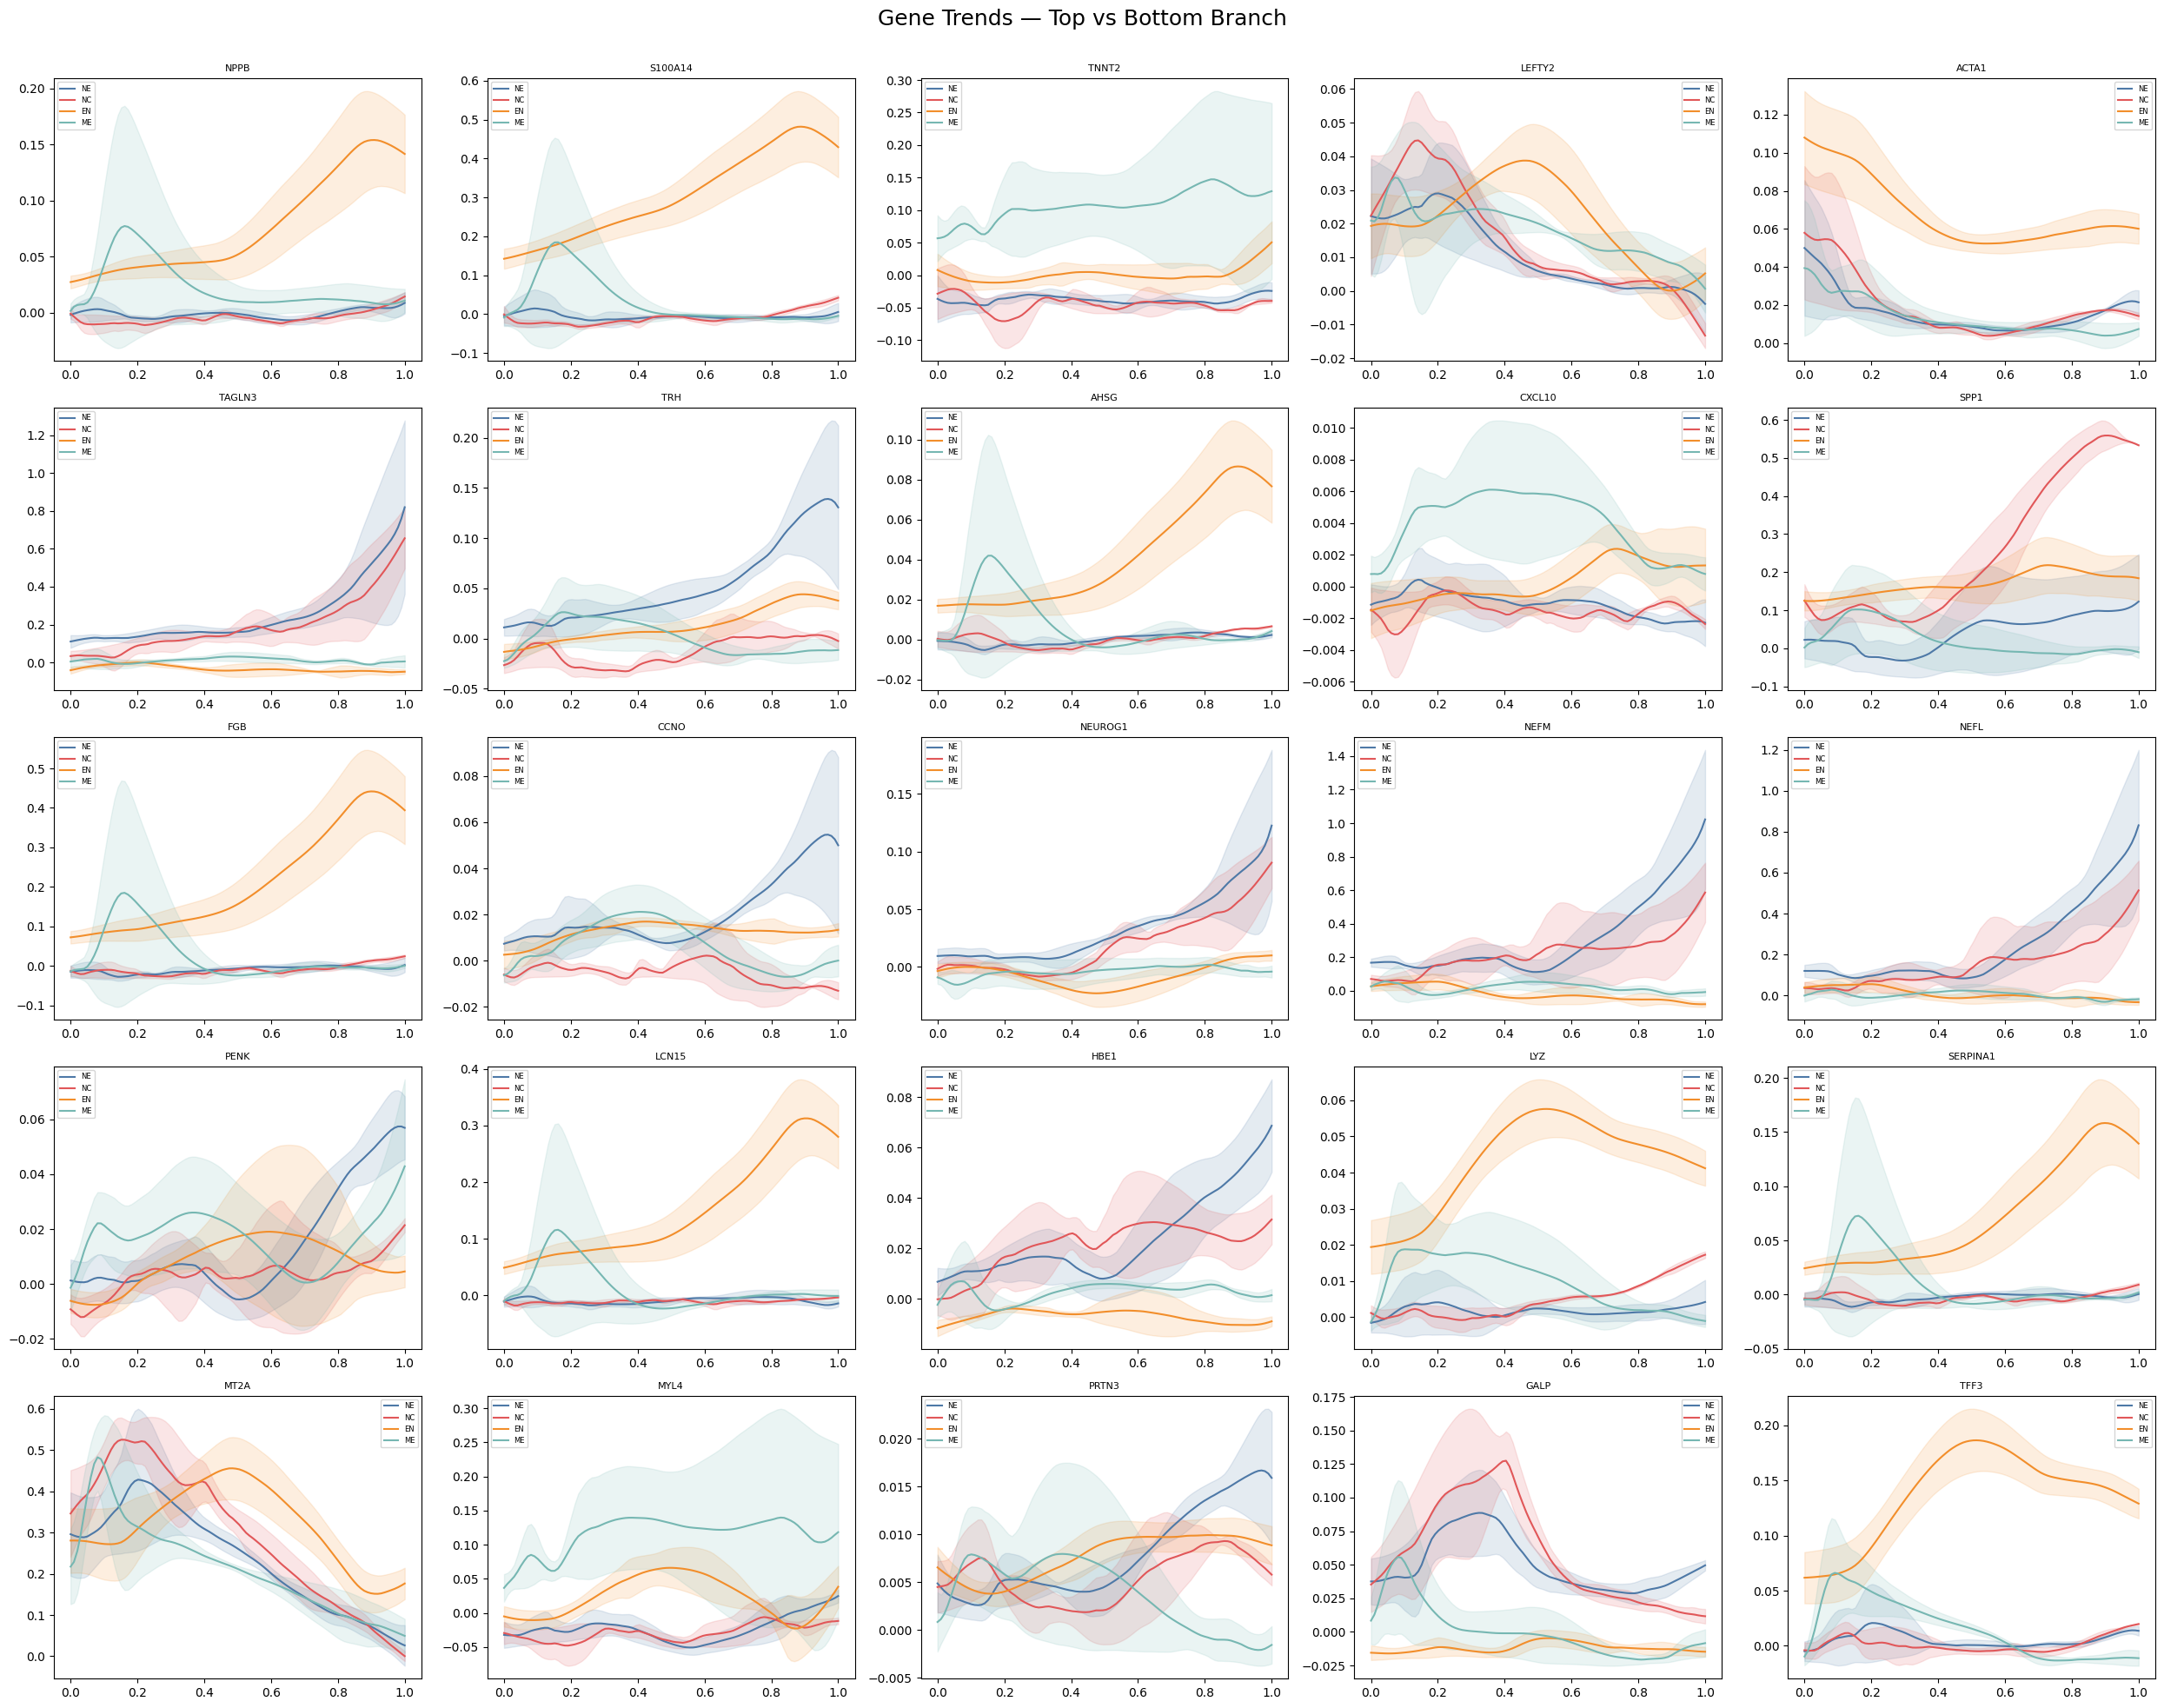

In [33]:
sc.pp.highly_variable_genes(adata, n_top_genes=25)
example_genes     = adata.var_names[adata.var['highly_variable']]
example_gene_mask = adata.var_names.isin(example_genes)


x_time = np.linspace(0, 1, list(mioflow_models.values())[0].trajectories.shape[0])

# Original data aggregated by time (from full adata)
t = adata.obs[time_column].astype(float)
obs_time_norm = (t - t.min()) / (t.max() - t.min())
adata_sel = adata[:, example_gene_mask]
data_df   = pd.DataFrame(adata_sel.X.toarray(), columns=example_genes)
data_df['t'] = obs_time_norm

n_genes = len(example_genes)
n_cols  = int(np.ceil(np.sqrt(n_genes)))
n_rows  = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, gene in enumerate(example_genes):
    ax = axes[i]
    for branch, tgs in trajectories_gene_space.items():
        decoded = tgs[:, :, example_gene_mask][:, :, i]   # (n_bins,)
        mean = decoded.mean(axis=1)
        std  = decoded.std(axis=1)
        color = branch_colors[branch]
        ax.plot(x_time, mean, color=color, label=branch)
        ax.fill_between(x_time, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_title(gene, fontsize=8)
    ax.legend(fontsize=6)

for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Gene Trends — Top vs Bottom Branch', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


# 8. Gene Trends - Gene List

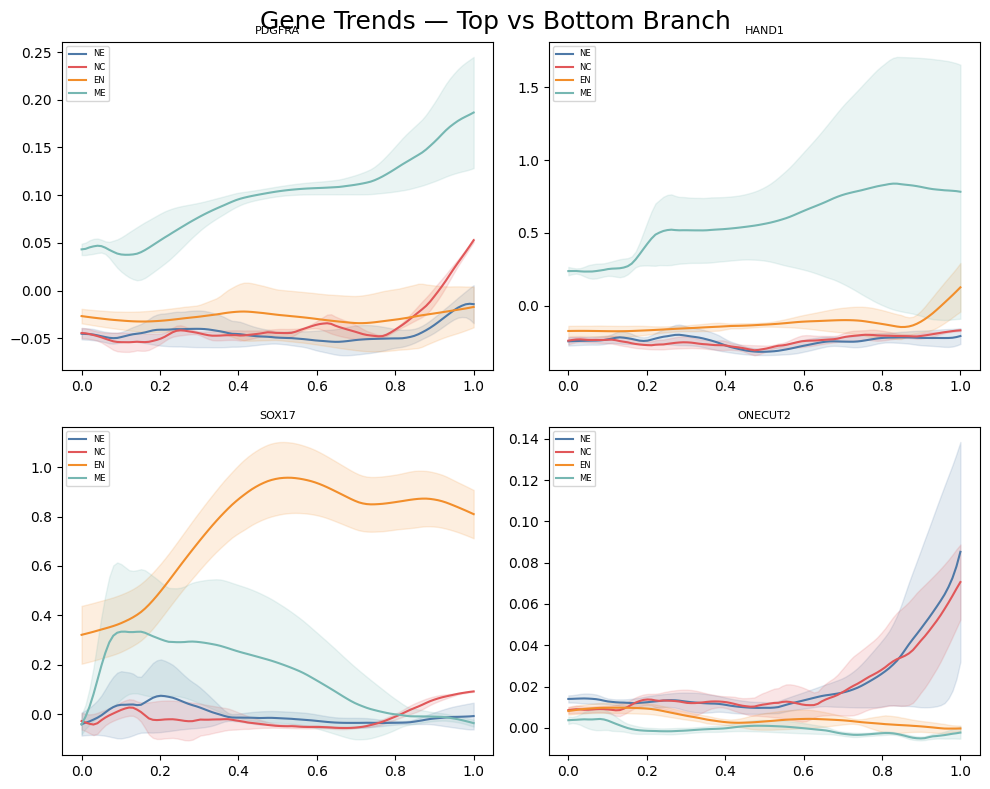

In [36]:
curated = ['PDGFRA', 'HAND1', 'SOX17', 'ONECUT2']
missing = [g for g in curated if g not in adata.var_names]
if missing:
    print(f"Warning: genes not found in adata: {missing}")

example_gene_mask = adata.var_names.isin(curated)
example_genes = adata.var_names[example_gene_mask]


x_time = np.linspace(0, 1, list(mioflow_models.values())[0].trajectories.shape[0])

# Original data aggregated by time (from full adata)
t = adata.obs[time_column].astype(float)
obs_time_norm = (t - t.min()) / (t.max() - t.min())
adata_sel = adata[:, example_gene_mask]
data_df   = pd.DataFrame(adata_sel.X.toarray(), columns=example_genes)
data_df['t'] = obs_time_norm

n_genes = len(example_genes)
n_cols  = int(np.ceil(np.sqrt(n_genes)))
n_rows  = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, gene in enumerate(example_genes):
    ax = axes[i]
    for branch, tgs in trajectories_gene_space.items():
        decoded = tgs[:, :, example_gene_mask][:, :, i]   # (n_bins,)
        mean = decoded.mean(axis=1)
        std  = decoded.std(axis=1)
        color = branch_colors[branch]
        ax.plot(x_time, mean, color=color, label=branch)
        ax.fill_between(x_time, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_title(gene, fontsize=8)
    ax.legend(fontsize=6)

for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Gene Trends — Top vs Bottom Branch', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


## Save trajectories for RiTINI

In [ ]:
output_path = 'data/processed/scRNAseq/'

for branch, model in mioflow_models.items():
    np.save(output_path + f'trajectories_latent_{branch}.npy', model.trajectories)
    np.save(output_path + f'trajectories_gene_space_{branch}.npy', trajectories_gene_space[branch])